In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import glob, os

fs_axislabel = 10
fs_figsubpanel = 14
fs_legend = 8

In [23]:
methods = {
    'patchavgmm':'Avg. Expression',
    'patchcelltypeabundance':'Cell type abundance',
    'stagate':'STAGATE',
    'utag':'UTAG',
    'canvas':'CANVAS'}

# Volcano plots

In [48]:
def make_volcanoplot_grid(dsetname, harm, ncols=3):
    harm = 'harm' if harm else 'noharm'
    fig, axs = plt.subplots(2, ncols, figsize=(ncols * 3, 6))
    for ax, method in zip(axs.flatten(), methods.keys()):
        if not os.path.exists(f'_results/{dsetname}_{method}_{harm}.h5ad'):
            ax.axis('off')
            continue
        d = sc.read_h5ad(f'_results/{dsetname}_{method}_{harm}.h5ad')
        info = d.uns['clustercc']
        ax.scatter(info['corr'], -np.log10(info['p']))
        ax.axhline(-np.log10(0.05/len(info)), color='gray', linestyle='--')
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_title(methods[method])
    for ax in axs.flatten()[len(methods):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(4, 5))
    for method in methods.keys():
        if not os.path.exists(f'_results/{dsetname}_{method}_{harm}.h5ad'):
            continue
        d = sc.read_h5ad(f'_results/{dsetname}_{method}_{harm}.h5ad')
        info = d.uns['clustercc']
        plt.scatter(info['corr'], -np.log10(info['p']), label=methods[method], alpha=0.5)
        plt.axhline(-np.log10(0.05/len(info)), color=plt.gca().collections[-1].get_facecolor(), linestyle='--')
        plt.legend()
    plt.tight_layout()
    plt.show()

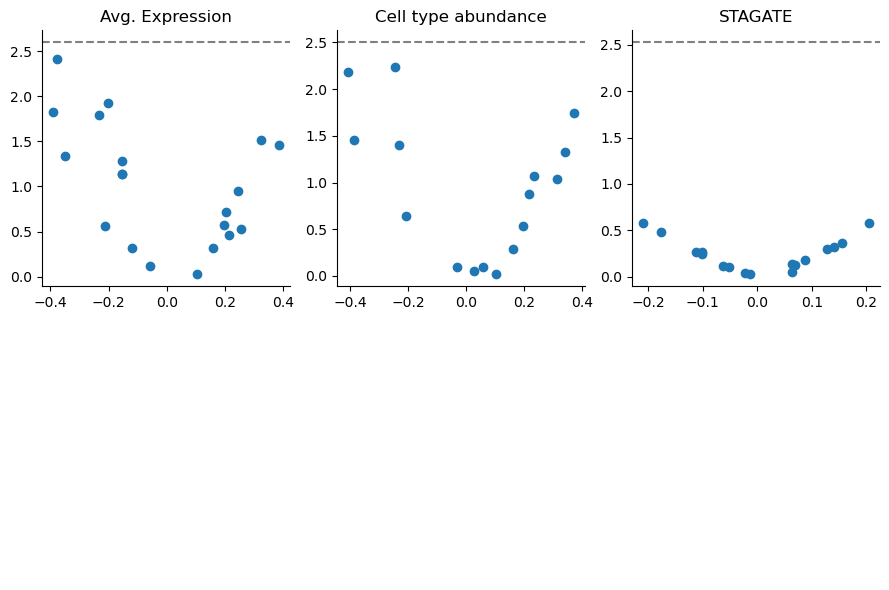

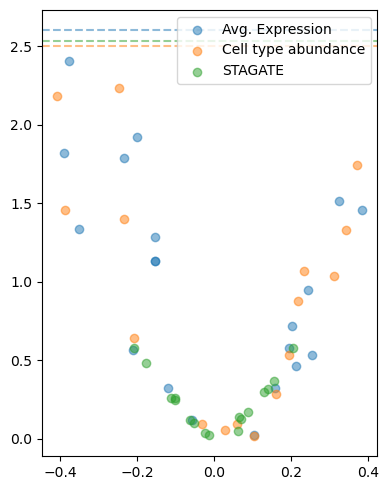

In [49]:
make_volcanoplot_grid('ALZ', True)

# Integration

In [72]:
def plot_perplexity(dsetname, harm, ax):
    harm = 'harm' if harm else 'noharm'
    plt.figure(figsize=(7, 3))
    N = -1
    for method in methods.keys():
        if not os.path.exists(f'_results/{dsetname}_{method}_{harm}.h5ad'):
            continue
        d = sc.read_h5ad(f'_results/{dsetname}_{method}_{harm}.h5ad')
        N = max(N, len(d.obs.sid.unique()))
        bins = np.arange(0, len(d.obs.sid.unique()), 0.5)
        res = ax.hist(d.obs.isi, bins=bins, alpha=0.5, density=True, label=methods[method])
        med = d.obs.isi.median()
        medy = res[0][np.where(res[1] >= med)[0][0]-1]
        c = res[2][0].get_facecolor()
        ax.plot([med, med], [0, 0.95*medy], color=c, alpha=1, lw=2)
    ax.set_xlabel('Sample integration (perplexity over samples)', fontsize=fs_axislabel)
    ax.set_ylabel('%Microniches (log-scale)', fontsize=fs_axislabel)
    ax.set_yscale('log')
    # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))
    ax.set_xlim(0, N)

    ax.legend(fontsize=fs_legend)
    ax.spines[['right','top']].set_visible(False)

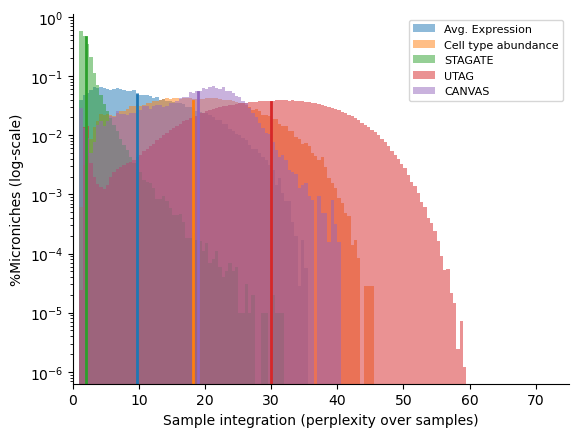

<Figure size 700x300 with 0 Axes>

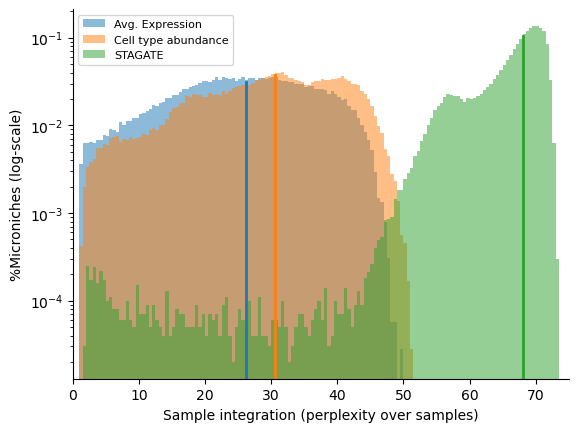

<Figure size 700x300 with 0 Axes>

In [73]:
plot_perplexity('ALZ', False, plt.gca())
plt.show()
plot_perplexity('ALZ', True, plt.gca())
plt.show()